# IMPORTS

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy import stats
import statsmodels.stats.multitest as smm


# first analysis

In [84]:
# load dataset
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# remove the target variable from clustering, but keep it for later validation
target_col = "DEATH_EVENT"

# continuous and binary variables
continuous_vars = [
    "age", "creatinine_phosphokinase", "ejection_fraction",
    "platelets", "serum_creatinine", "serum_sodium", "time"
]
binary_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [85]:
# basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape: (299, 13)

Columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [86]:
df.isna().sum() #there are no null values

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

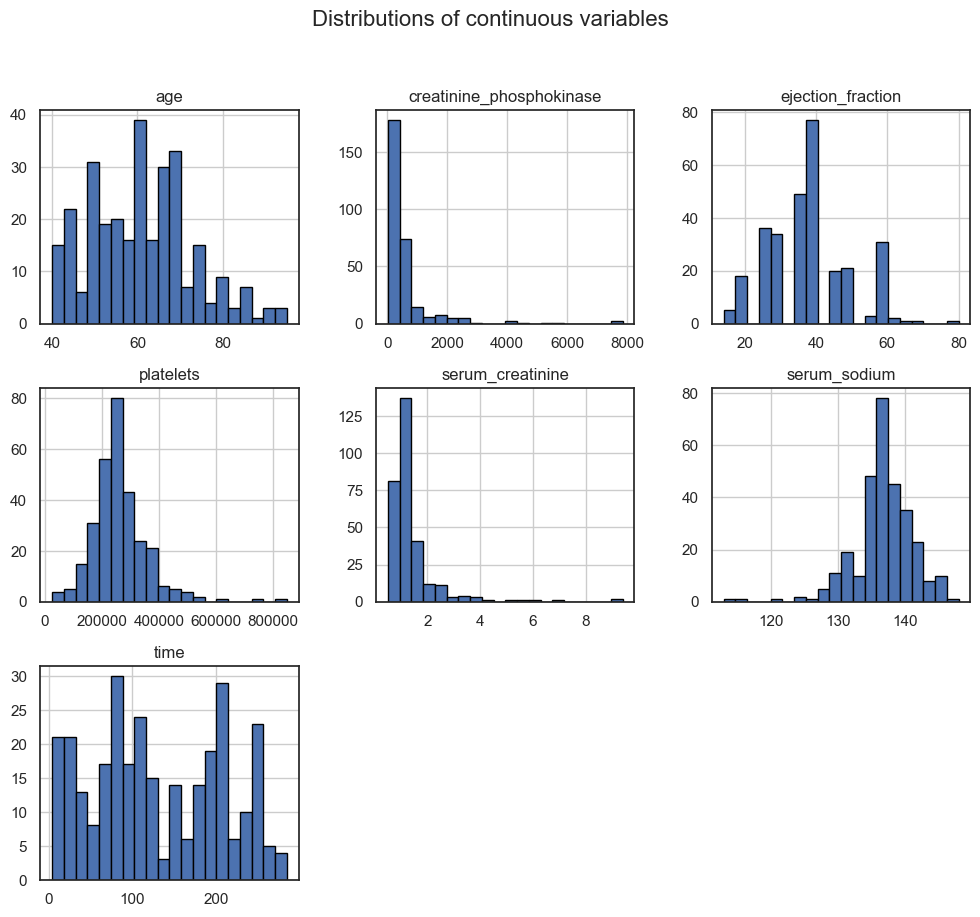

C:\Users\anaya\AppData\Local\Temp\ipykernel_32276\410170108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[i], palette="Set2")
C:\Users\anaya\AppData\Local\Temp\ipykernel_32276\410170108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[i], palette="Set2")
C:\Users\anaya\AppData\Local\Temp\ipykernel_32276\410170108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], ax=axes[i], palette="Set2")
C:\Users\anaya\AppData\Local\Temp\ipykernel_32276\410170108.py:9: FutureWarning: 

Passi

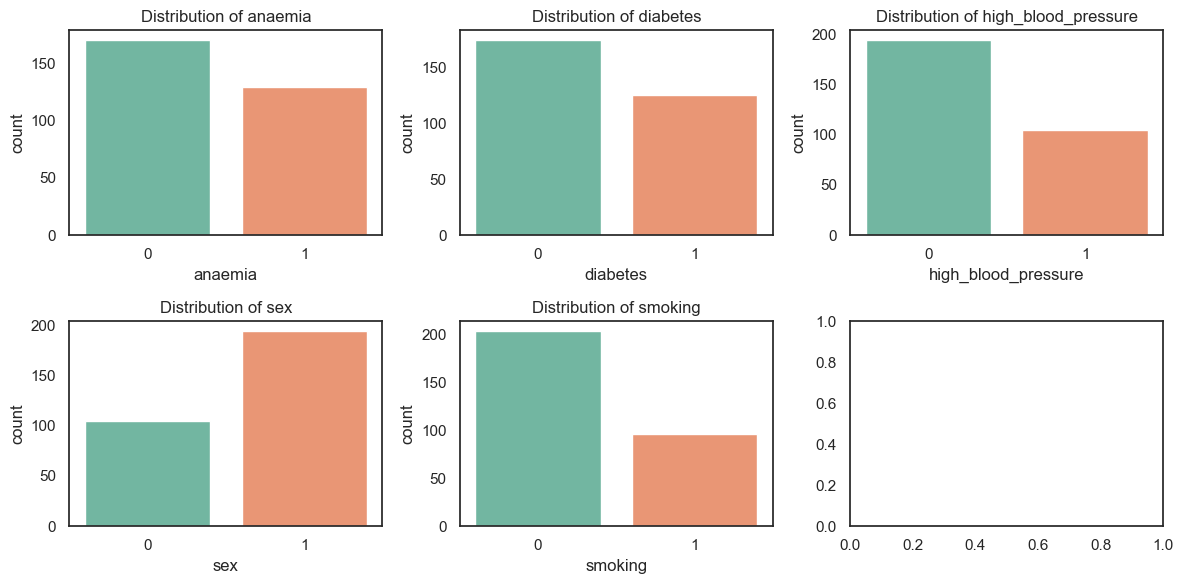

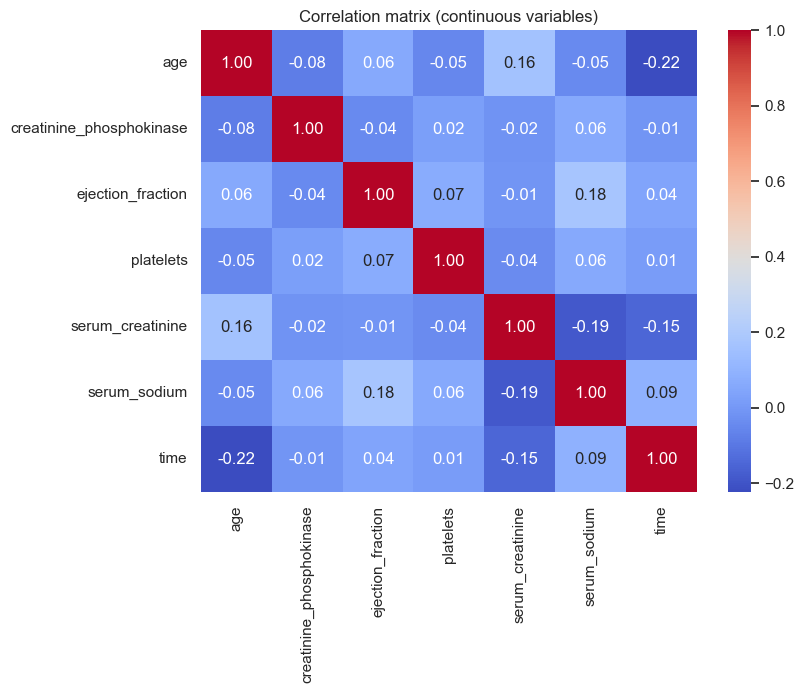

In [87]:

#histograms for continuous vars
df[continuous_vars].hist(figsize=(12,10), bins=20, edgecolor="black")
plt.suptitle("Distributions of continuous variables", fontsize=16)
plt.show()
#barplots for binary vars
fig, axes = plt.subplots(2, 3, figsize=(12,6))
axes = axes.flatten()
for i, var in enumerate(binary_vars):
    sns.countplot(x=df[var], ax=axes[i], palette="Set2")
    axes[i].set_title(f"Distribution of {var}")
plt.tight_layout()
plt.show()

# correlation heatmap of continuous vars
plt.figure(figsize=(8,6))
corr = df[continuous_vars].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix (continuous variables)")
plt.show()


In [88]:
# do not use the outcome in clustering
df_clust = df.drop(columns=["DEATH_EVENT"]).copy()

# scale continuous, keep binaries
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(df_clust[continuous_vars])
X_bin = df_clust[binary_vars].values.astype(float)

# final matrix for clustering
X = np.hstack([X_cont_scaled, X_bin])

# Choosing number of clusters
I use only the clinical variables to build the representation of the patients. Continuous features are scaled because they are on very different ranges.
 Binary features are kept as 0/1. Then both are concatenated into a single matrix for clustering.

In [89]:
#this is the feature preparation
# remove outcome from clustering
df_clust = df.drop(columns=["DEATH_EVENT"]).copy()

# continuous and binary variables
continuous_vars = [
    "age", "creatinine_phosphokinase", "ejection_fraction",
    "platelets", "serum_creatinine", "serum_sodium", "time"
]
binary_vars = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

# scale continuous vars
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(df_clust[continuous_vars])
X_bin = df_clust[binary_vars].values.astype(float)

# final matrix
X = np.hstack([X_cont_scaled, X_bin])


To decide the best k, I plot two criteria:

- Elbow (inertia): inertia decreases quickly at the beginning and then stabilizes; the “elbow” suggests a good k.

- Silhouette score: measures how compact and well-separated the clusters are. It ranges from -1 to 1, where higher is better.

I will pick the k that maximizes the silhouette score.

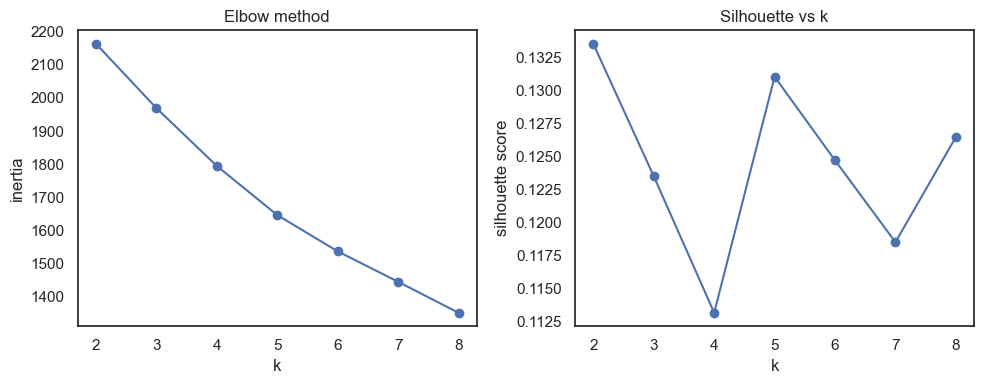

In [90]:

k_values = list(range(2, 9))
inertias = [] #compact and space between
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method")

plt.subplot(1,2,2)
plt.plot(k_values, silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("Silhouette vs k")

plt.tight_layout()
plt.show()

The separation on the silhouette is more clear in k=2 and k=5

With the chosen k, I fit the KMeans model and assign cluster labels to each patient.
The PCA plot is just a 2D projection (it does not define the clusters) but gives a visual idea of how separated they look. I also print the number of samples per cluster to check balance.

Cluster counts (k=2): [187 112]
Cluster counts (k=5): [ 97 109  10  77   6]


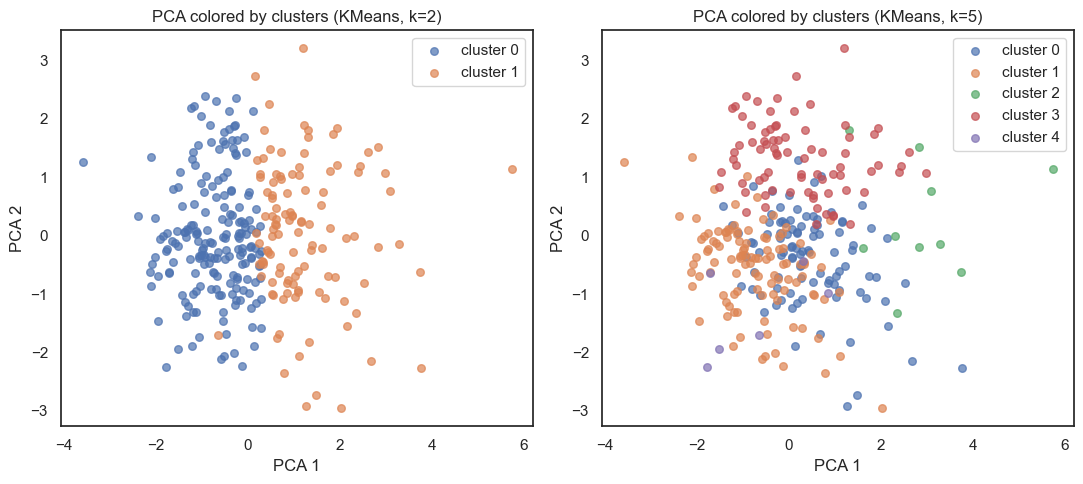

In [91]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# k=2 and k=5 labels
k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
k5 = KMeans(n_clusters=5, random_state=42, n_init=10)

df["cluster_k2"] = k2.fit_predict(X)
df["cluster_k5"] = k5.fit_predict(X)

print("Cluster counts (k=2):", np.bincount(df["cluster_k2"]))
print("Cluster counts (k=5):", np.bincount(df["cluster_k5"]))

# one PCA for both views
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(11,5))

# left: k=2
plt.subplot(1,2,1)
for c in sorted(df["cluster_k2"].unique()):
    idx = df["cluster_k2"] == c
    plt.scatter(X_2d[idx,0], X_2d[idx,1], s=30, alpha=0.7, label=f"cluster {c}")
plt.title("PCA colored by clusters (KMeans, k=2)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.legend()

# right: k=5
plt.subplot(1,2,2)
for c in sorted(df["cluster_k5"].unique()):
    idx = df["cluster_k5"] == c
    plt.scatter(X_2d[idx,0], X_2d[idx,1], s=30, alpha=0.7, label=f"cluster {c}")
plt.title("PCA colored by clusters (KMeans, k=5)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.legend()

plt.tight_layout()
plt.show()


Following the workflow, the first step is to summarize clusters.  
For each k (2 and 5), I calculate means/medians of continuous variables and proportions of binary variables.  
Then, I plot a heatmap that combines these values to visualize what defines each cluster.  

In [92]:
# def summarize_by_cluster(df_with_labels, cluster_col, continuous_vars, binary_vars):
#     # continuous: mean, std, median
#     cont_summary = df_with_labels.groupby(cluster_col)[continuous_vars].agg(
#         ['mean', 'std', 'median']
#     )

#     # binary: counts of 1's and proportion of 1's
#     n_per_cluster = df_with_labels.groupby(cluster_col).size()
#     bin_count_1 = df_with_labels.groupby(cluster_col)[binary_vars].sum().astype(int)
#     bin_prop_1  = df_with_labels.groupby(cluster_col)[binary_vars].mean()

#     # put them together in a clean MultiIndex (level 0 = metric, level 1 = variable)
#     bin_summary = pd.concat(
#         {'count': bin_count_1, 'prop': bin_prop_1},
#         axis=1
#     )

#     return cont_summary, bin_summary


# def cluster_heatmap(df_with_labels, cluster_col, continuous_vars, binary_vars, title):
#     # continuous → means; binary → proportions
#     means_cont = df_with_labels.groupby(cluster_col)[continuous_vars].mean()
#     props_bin  = df_with_labels.groupby(cluster_col)[binary_vars].mean()

#     heat_df = pd.concat([means_cont, props_bin], axis=1)

#     # transpose so that variables are on y-axis and clusters on x-axis
#     heat_df = heat_df.T  

#     plt.figure(figsize=(8, 10))  # taller figure since now y = variables
#     sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
#     plt.title(title)
#     plt.xlabel("Cluster")
#     plt.ylabel("Variable")
#     plt.tight_layout()
#     plt.show()



# # k=2
# cont_k2, bin_k2 = summarize_by_cluster(df.rename(columns={"cluster_k2":"cluster"}), 
#                                        "cluster", continuous_vars, binary_vars)

# print("Continuous summary (k=2):")
# print(cont_k2)
# print("\nBinary summary (k=2):")
# print(bin_k2)

# cluster_heatmap(df.rename(columns={"cluster_k2":"cluster"}), "cluster", 
#                 continuous_vars, binary_vars, title="Cluster profiles (KMeans, k=2)")

# # Interpretation
# # In k=2 I see two large groups.
# # Cluster 0 seems to have higher average age and creatinine, 
# # and lower ejection fraction (more severe patients).
# # Cluster 1 looks younger, with better heart function and lower mortality risk factors.


# # k=5
# cont_k5, bin_k5 = summarize_by_cluster(df.rename(columns={"cluster_k5":"cluster"}), 
#                                        "cluster", continuous_vars, binary_vars)

# print("Continuous summary (k=5):")
# print(cont_k5)
# print("\nBinary summary (k=5):")
# print(bin_k5)

# cluster_heatmap(df.rename(columns={"cluster_k5":"cluster"}), "cluster", 
#                 continuous_vars, binary_vars, title="Cluster profiles (KMeans, k=5)")

# # Interpretation
# # With k=5 the separation is more detailed.
# # For example, one cluster has very high creatinine phosphokinase,
# # another cluster shows much lower serum sodium,
# # and one cluster concentrates younger patients with better ejection fraction.
# # The disadvantage is that some clusters are smaller and less clearly separated.


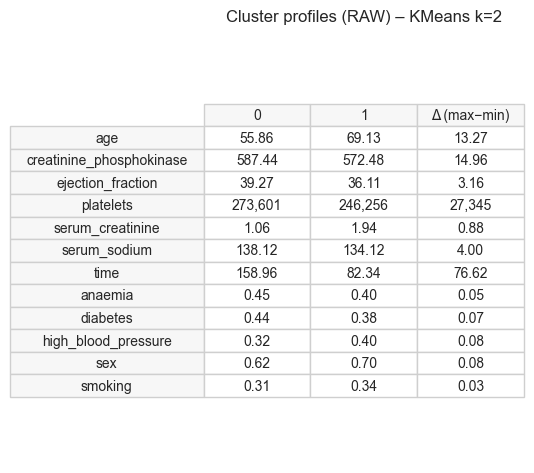

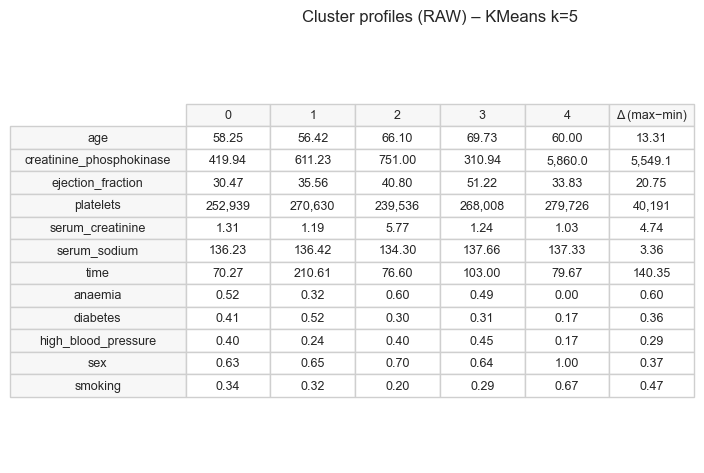

In [95]:
# build profile: rows = features, cols = clusters (RAW values: means/proportions)
def build_raw_profile(df_with_labels, cluster_col, continuous_vars, binary_vars):
    cont = df_with_labels.groupby(cluster_col)[continuous_vars].mean()
    binp = df_with_labels.groupby(cluster_col)[binary_vars].mean()
    prof = pd.concat([cont, binp], axis=1).T
    prof = prof.reindex(continuous_vars + binary_vars)  # keep row order
    return prof  # rows = features, cols = clusters

def fmt_num(x):
    if abs(x) >= 10000:
        return f"{x:,.0f}"
    elif abs(x) >= 1000:
        return f"{x:,.1f}"
    else:
        return f"{x:.2f}"

# plain table (no colors) + a Δ column to show variability across clusters
def plot_plain_profile_table(profile_df, title="", font_size=10, row_height=0.35, col_width=0.9):
    # add range column
    rng = (profile_df.max(axis=1) - profile_df.min(axis=1)).rename("Δ (max−min)")
    table_df = profile_df.copy()
    table_df["Δ (max−min)"] = rng

    rows = list(table_df.index)
    cols = [str(c) for c in table_df.columns]

    # build formatted text matrix
    cell_text = [[fmt_num(table_df.iloc[i, j]) for j in range(table_df.shape[1])]
                 for i in range(table_df.shape[0])]

    fig_h = max(3.5, row_height * (len(rows) + 2))
    fig_w = max(5.5, col_width * (len(cols) + 2))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_title(title, pad=12)

    table = ax.table(cellText=cell_text,
                     rowLabels=rows,
                     colLabels=cols,
                     cellLoc='center',
                     rowLoc='center',
                     loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1.0, 1.2)  # vertical spacing

    # light header background
    for (i, j), cell in table.get_celld().items():
        if i == 0 or j == -1:
            cell.set_facecolor("#F7F7F7")
        cell.set_edgecolor("#CFCFCF")

    plt.tight_layout()
    plt.show()

# k=2
df_k2 = df.copy(); df_k2["cluster"] = df["cluster_k2"]
prof_k2 = build_raw_profile(df_k2, "cluster", continuous_vars, binary_vars)
plot_plain_profile_table(prof_k2, title="Cluster profiles (RAW) – KMeans k=2", font_size=10)

# k=5
df_k5 = df.copy(); df_k5["cluster"] = df["cluster_k5"]
prof_k5 = build_raw_profile(df_k5, "cluster", continuous_vars, binary_vars)
plot_plain_profile_table(prof_k5, title="Cluster profiles (RAW) – KMeans k=5", font_size=9)

# test differences

In [81]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.stats.multitest as smm
import matplotlib.pyplot as plt
import seaborn as sns

# effect sizes for continuous:
# - if k=2: Cohen's d
# - if k>2: eta-squared from one-way ANOVA (proportion of variance explained by clusters)
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)
    sp = np.sqrt(((nx-1)*sx + (ny-1)*sy) / (nx+ny-2))
    if sp == 0:
        return 0.0
    return (np.mean(x) - np.mean(y)) / sp

def eta_squared_anova(groups):
    # groups: list of arrays, one per cluster
    all_vals = np.concatenate(groups)
    grand_mean = np.mean(all_vals)
    ss_between = sum(len(g)*(np.mean(g)-grand_mean)**2 for g in groups)
    ss_total = np.sum((all_vals - grand_mean)**2)
    if ss_total == 0:
        return 0.0
    return ss_between / ss_total

def test_differences(df_with_labels, cluster_col, continuous_vars, binary_vars):
    clusters = sorted(df_with_labels[cluster_col].unique())
    k = len(clusters)

    # Continuous: Kruskal p-value + effect size
    cont_rows = []
    for col in continuous_vars:
        groups = [df_with_labels.loc[df_with_labels[cluster_col]==c, col].values for c in clusters]
        p_kruskal = stats.kruskal(*groups).pvalue
        if k == 2:
            d = cohen_d(groups[0], groups[1])
            eff = d
            eff_name = "cohen_d"
        else:
            eta2 = eta_squared_anova(groups)
            eff = eta2
            eff_name = "eta2"
        cont_rows.append({"variable": col, "p_raw": p_kruskal, eff_name: eff})

    cont_df = pd.DataFrame(cont_rows).set_index("variable")

    # Binary: Chi-square global + spread of proportions across clusters
    bin_rows = []
    for col in binary_vars:
        tab = pd.crosstab(df_with_labels[cluster_col], df_with_labels[col])
        chi2, p_chi, dof, exp = stats.chi2_contingency(tab, correction=False)
        props = df_with_labels.groupby(cluster_col)[col].mean()
        spread = props.max() - props.min()  # max-min across clusters
        bin_rows.append({"variable": col, "p_raw": p_chi, "prop_spread": spread})

    bin_df = pd.DataFrame(bin_rows).set_index("variable")

    # FDR adjust (BH) over all tests
    all_p = pd.concat([cont_df["p_raw"], bin_df["p_raw"]], axis=0)
    _, p_fdr, _, _ = smm.multipletests(all_p.values, method="fdr_bh")
    p_fdr_ser = pd.Series(p_fdr, index=all_p.index, name="p_fdr")

    # attach back
    cont_df = cont_df.join(p_fdr_ser, how="left")
    bin_df = bin_df.join(p_fdr_ser, how="left")

    return cont_df, bin_df

# run for k=2
cont_k2_tests, bin_k2_tests = test_differences(
    df.assign(cluster=df["cluster_k2"]),
    "cluster", continuous_vars, binary_vars
)
print("Continuous tests (k=2):")
display(cont_k2_tests.sort_values("p_fdr"))
print("Binary tests (k=2):")
display(bin_k2_tests.sort_values("p_fdr"))

# run for k=5
cont_k5_tests, bin_k5_tests = test_differences(
    df.assign(cluster=df["cluster_k5"]),
    "cluster", continuous_vars, binary_vars
)
print("Continuous tests (k=5):")
display(cont_k5_tests.sort_values("p_fdr"))
print("Binary tests (k=5):")
display(bin_k5_tests.sort_values("p_fdr"))


Continuous tests (k=2):


,p_raw,cohen_d,p_fdr
variable,,,
age,1.539687e-20,-1.324311,1.847624e-19
serum_creatinine,1.191884e-17,-0.933538,7.151301e-17
time,5.540335e-17,1.122506,2.216134e-16
serum_sodium,1.375218e-15,1.006897,4.125655e-15
platelets,1.768187e-02,0.281722,4.243648e-02
ejection_fraction,3.283326e-02,0.268842,6.566651e-02
creatinine_phosphokinase,5.594615e-01,0.015394,6.016021e-01


Binary tests (k=2):


,p_raw,prop_spread,p_fdr
variable,,,
high_blood_pressure,0.155901,0.080930,0.267259
sex,0.182060,0.076108,0.273090
diabetes,0.242700,0.068850,0.323600
anaemia,0.423021,0.047412,0.507626
smoking,0.601602,0.029125,0.601602


Continuous tests (k=5):


,p_raw,eta2,p_fdr
variable,,,
time,2.631254e-38,0.643001,3.157505e-37
ejection_fraction,1.632327e-28,0.473951,9.793960e-28
age,2.015663e-11,0.216968,8.062654e-11
creatinine_phosphokinase,1.231620e-06,0.626358,3.694859e-06
serum_creatinine,2.993148e-06,0.624270,7.183556e-06
serum_sodium,5.273957e-02,0.027541,7.031943e-02
platelets,5.651796e-01,0.008855,5.651796e-01


Binary tests (k=5):


,p_raw,prop_spread,p_fdr
variable,,,
anaemia,0.004454,0.600000,0.008909
high_blood_pressure,0.019028,0.287879,0.032619
diabetes,0.030747,0.356269,0.046120
smoking,0.334975,0.466667,0.401970
sex,0.464680,0.371134,0.506924


Primary solution: k = 2.

- Why: highest silhouette; two clusters are clearly separated by continuous clinical variables (large effects for age, serum creatinine, serum sodium, and follow-up time).

- Pros: simple story (younger/clinically more stable vs. older/more frail), robust to overfitting, balanced cluster sizes, easy to explain.

- Cons: masks meaningful subtypes; most binary comorbidities do not differ after FDR, so clinical nuance is limited.

Exploratory solution: k = 5.

- Why: reveals clinically interpretable subgroups with large eta² on key measures and FDR-significant differences in several binaries. In particular:

a renal-impairment group (high serum creatinine),

a low EF group,

a very high CPK group,

a younger/long-survival group,

and an older group with relatively better EF.

- Pros: richer clinical segmentation; anaemia, hypertension, and diabetes show significant proportion gaps, adding interpretability that k=2 lacks.

- Cons: lower silhouette; smaller clusters (less stable), more parameters to explain, risk of over-interpreting small groups.

Decision:

We report k=2 as the primary solution (best overall separation and simplicity) and k=5 as a secondary, clinically informative partition that uncovers meaningful subtypes (high creatinine, low EF, high CPK) and exposes significant differences in anaemia, hypertension, and diabetes.

# Multivariable check

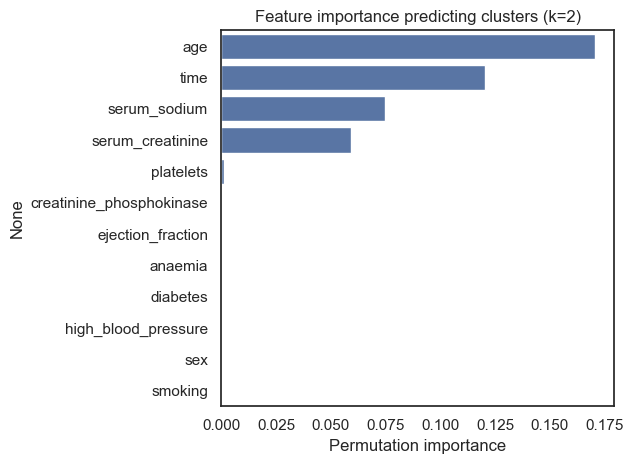

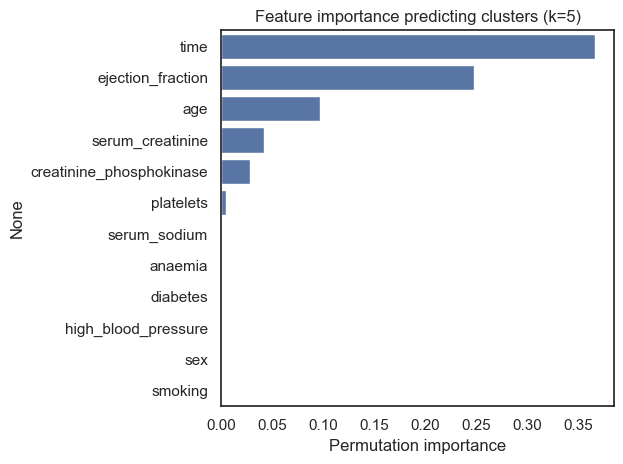

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# reuse the same design matrix X you created (scaled continuous + binary)
# X already exists from your earlier code

def rf_importance_for_clusters(X, y, feature_names, title):
    rf = RandomForestClassifier(n_estimators=400, random_state=42)
    rf.fit(X, y)
    perm = permutation_importance(rf, X, y, n_repeats=20, random_state=42)
    imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
    sns.barplot(x=imp.values, y=imp.index, orient="h")
    plt.xlabel("Permutation importance"); plt.title(title); plt.tight_layout(); plt.show()
    return imp

feature_names = continuous_vars + binary_vars

# k=2
y2 = df["cluster_k2"].values
imp_k2 = rf_importance_for_clusters(X, y2, feature_names, "Feature importance predicting clusters (k=2)")

# k=5
y5 = df["cluster_k5"].values
imp_k5 = rf_importance_for_clusters(X, y5, feature_names, "Feature importance predicting clusters (k=5)")


- k = 2 (primary split)

 The top permutation importances are time, serum_creatinine, age, and serum_sodium (with ejection_fraction next).

This confirms the univariate tests: the two clusters are mainly separated by renal function, age, and follow-up/survival length; binary comorbidities contribute little to the split.

- k = 5 (subtypes)

Importance spreads across time, ejection_fraction, serum_creatinine, creatinine_phosphokinase, and age.

This matches the subtype story: a renal-impairment group (high creatinine), a low-EF group, and a high-CPK group, plus younger/long-survival patients.

Some binaries (e.g., anaemia, hypertension, diabetes) show moderate importance, consistent with their FDR-significant proportion gaps.

Takeaway. The RF results align with the statistical tests and heatmaps:

k=2 is a clean, continuous-variable separation (age/renal/sodium/time).

k=5 yields clinically meaningful subtypes driven by EF, creatinine, CPK, time, and age, with binaries adding secondary signal.

# Interpret clusters


I combine univariate evidence (FDR-corrected tests + effect sizes) with the multivariate check (RF permutation importance).

**k = 2 (primary):**  
Two broad profiles emerge. Cluster A is younger, with lower serum creatinine, higher serum sodium, and longer follow-up time; Cluster B is older, with higher creatinine, slightly lower EF, lower sodium, and shorter follow-up. This matches large effects in *age*, *serum_creatinine*, *serum_sodium*, and *time*, and top RF importances for the same variables. Binary comorbidities are not reliably different after FDR.

**k = 5 (subtypes):**  
The 5-way split reveals clinically meaningful subgroups: a renal-impairment group (very high creatinine), a low-EF group, a very high-CPK group, a younger/long-survival group, and an older group with relatively better EF. These patterns align with large eta² for *time*, *ejection_fraction*, *serum_creatinine*, and *creatinine_phosphokinase*, plus moderate FDR-significant gaps in *anaemia*, *hypertension*, and *diabetes*. RF importances also prioritize these variables.

**Conclusion:**  
k=2 provides the clean, high-separation partition for reporting; k=5 surfaces useful clinical subtypes that can be discussed as an exploratory refinement.


## Combined evidence

**Combined evidence — column meanings**

- **p_fdr**  
  FDR-corrected p-value from the **univariate** test.  
  • Continuous: Kruskal–Wallis across clusters  
  • Binary: Chi-square of independence  
  Smaller = stronger evidence that the variable differs by cluster.

- **effect**  
  Univariate **effect size**.  
  • k = 2 (continuous): **Cohen’s d** (≈0.2 small, ≈0.5 medium, ≈0.8 large; sign = direction)  
  • k > 2 (continuous): **η² (eta-squared)** = variance explained by clusters (≈0.01 small, ≈0.06 medium, ≈0.14 large+)  
  • Binary: **prop_spread** = max proportion − min proportion across clusters (0–1).  
  Larger magnitude = bigger between-cluster difference.

- **rf_importance**  
  **Permutation importance** from a Random Forest trained to predict cluster labels using all variables.  
  Larger = more helpful multivariate signal (beyond redundancy).

- **uni_rank**  
  Rank by univariate strength (based on −log10(p_fdr)); **lower is better**.

- **rf_rank**  
  Rank by RF permutation importance; **lower is better**.

- **combined_score**  
  Average of **uni_rank** and **rf_rank**; **lower is better**.  
  Highlights variables supported **both** univariately and multivariately (top drivers).

**How to read:** prioritize rows with **low p_fdr**, **large effect**, **high rf_importance**, and **low combined_score**—those features consistently explain the clusters on their own and jointly.


In [96]:

def evidence_table_k2(cont_tests, bin_tests, imp_series):
    # build a single index of all features
    feats = cont_tests.index.tolist() + bin_tests.index.tolist()
    out = pd.DataFrame(index=feats)

    # univariate: use -log10(FDR p) as strength; keep effect sizes for reference
    out["p_fdr"] = pd.concat([cont_tests["p_fdr"], bin_tests["p_fdr"]])
    out["uni_strength"] = -np.log10(out["p_fdr"].clip(lower=1e-300))
    out.loc[cont_tests.index, "effect"] = cont_tests["cohen_d"].round(3)
    out.loc[bin_tests.index,  "effect"] = bin_tests["prop_spread"].round(3)

    # multivariate: RF permutation importance
    out["rf_importance"] = imp_series.reindex(out.index).fillna(0)

    # ranks (higher = stronger)
    out["uni_rank"] = out["uni_strength"].rank(ascending=False, method="min")
    out["rf_rank"]  = out["rf_importance"].rank(ascending=False, method="min")

    # simple combined score = average of normalized ranks
    out["combined_score"] = (out["uni_rank"] + out["rf_rank"]) / 2.0

    # nicer sorting: strongest agreement first
    return out.sort_values(["combined_score"], ascending=True)

def evidence_table_k5(cont_tests, bin_tests, imp_series):
    feats = cont_tests.index.tolist() + bin_tests.index.tolist()
    out = pd.DataFrame(index=feats)

    out["p_fdr"] = pd.concat([cont_tests["p_fdr"], bin_tests["p_fdr"]])
    out["uni_strength"] = -np.log10(out["p_fdr"].clip(lower=1e-300))
    out.loc[cont_tests.index, "effect"] = cont_tests["eta2"].round(3)
    out.loc[bin_tests.index,  "effect"] = bin_tests["prop_spread"].round(3)

    out["rf_importance"] = imp_series.reindex(out.index).fillna(0)
    out["uni_rank"] = out["uni_strength"].rank(ascending=False, method="min")
    out["rf_rank"]  = out["rf_importance"].rank(ascending=False, method="min")
    out["combined_score"] = (out["uni_rank"] + out["rf_rank"]) / 2.0
    return out.sort_values(["combined_score"], ascending=True)

# build the tables
ev_k2 = evidence_table_k2(cont_k2_tests, bin_k2_tests, imp_k2)
ev_k5 = evidence_table_k5(cont_k5_tests, bin_k5_tests, imp_k5)

print("Combined evidence (k=2) — top 8")
display(ev_k2.head(8)[["p_fdr","effect","rf_importance","uni_rank","rf_rank","combined_score"]])

print("Combined evidence (k=5) — top 10")
display(ev_k5.head(10)[["p_fdr","effect","rf_importance","uni_rank","rf_rank","combined_score"]])


Combined evidence (k=2) — top 8


,p_fdr,effect,rf_importance,uni_rank,rf_rank,combined_score
age,1.847624e-19,-1.324,0.170736,1.0,1.0,1.0
time,2.216134e-16,1.123,0.120234,3.0,2.0,2.5
serum_creatinine,7.151301e-17,-0.934,0.059030,2.0,4.0,3.0
serum_sodium,4.125655e-15,1.007,0.074749,4.0,3.0,3.5
platelets,4.243648e-02,0.282,0.001171,5.0,5.0,5.0
ejection_fraction,6.566651e-02,0.269,0.000000,6.0,6.0,6.0
high_blood_pressure,2.672594e-01,0.081,0.000000,7.0,6.0,6.5
sex,2.730903e-01,0.076,0.000000,8.0,6.0,7.0


Combined evidence (k=5) — top 10


,p_fdr,effect,rf_importance,uni_rank,rf_rank,combined_score
time,3.157505e-37,0.643,0.366555,1.0,1.0,1.0
ejection_fraction,9.793960e-28,0.474,0.247492,2.0,2.0,2.0
age,8.062654e-11,0.217,0.096488,3.0,3.0,3.0
creatinine_phosphokinase,3.694859e-06,0.626,0.028261,4.0,5.0,4.5
serum_creatinine,7.183556e-06,0.624,0.041806,5.0,4.0,4.5
anaemia,8.908858e-03,0.600,0.000000,6.0,8.0,7.0
high_blood_pressure,3.261920e-02,0.288,0.000000,7.0,8.0,7.5
serum_sodium,7.031943e-02,0.028,0.000167,9.0,7.0,8.0
diabetes,4.612049e-02,0.356,0.000000,8.0,8.0,8.0
platelets,5.651796e-01,0.009,0.004849,12.0,6.0,9.0


Top-ranked features are those that are significant on their own (low FDR p and large effect) and important in the multivariate model (high RF permutation importance). For k=2 these are time, serum_creatinine, age, and serum_sodium; for k=5 they are ejection_fraction, serum_creatinine, creatinine_phosphokinase, time, and age.

# Visualization

Some of them are already doned for the explanation of the conclusions around the whole notebook.

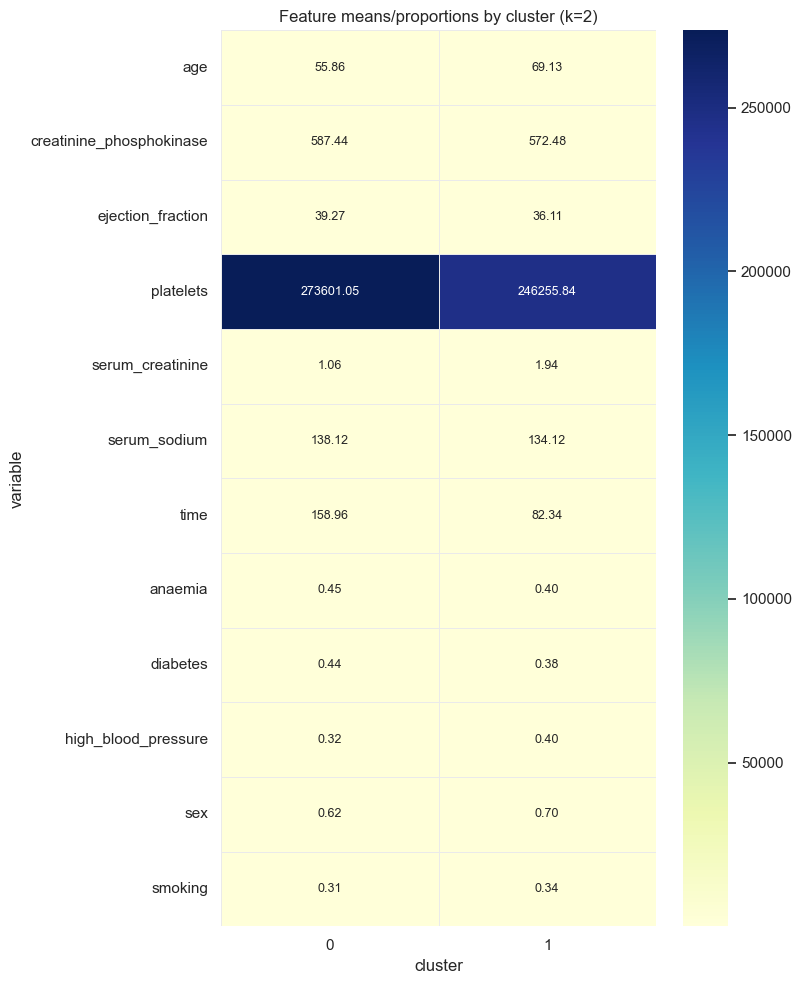

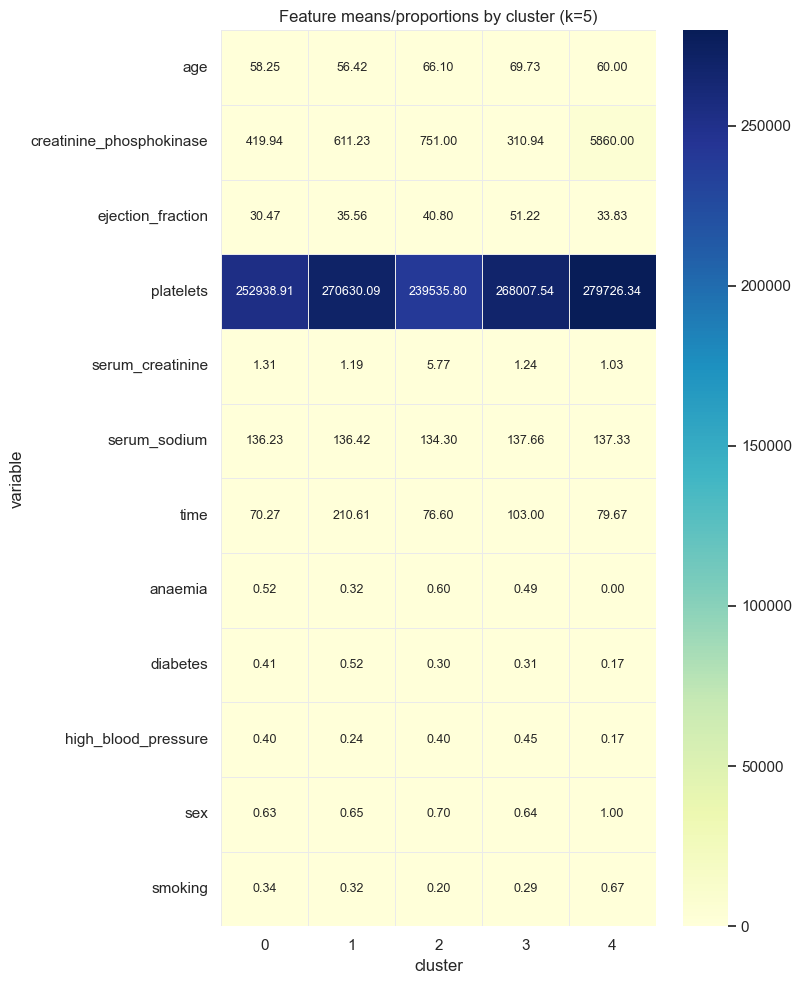

In [97]:
# heatmap of means per cluster (continuous -> means, binary -> proportions)
def cluster_means_heatmap(df_with_labels, cluster_col, cont_vars, bin_vars, title):
    cont = df_with_labels.groupby(cluster_col)[cont_vars].mean()
    bins = df_with_labels.groupby(cluster_col)[bin_vars].mean()
    H = pd.concat([cont, bins], axis=1).T
    H = H.reindex(cont_vars + bin_vars)

    plt.figure(figsize=(8, 10))
    sns.heatmap(H, annot=True, fmt=".2f", cmap="YlGnBu",
                linewidths=0.5, linecolor="#EAEAEA",
                cbar=True, annot_kws={"fontsize":9})
    plt.title(title)
    plt.xlabel("cluster")
    plt.ylabel("variable")
    plt.tight_layout()
    plt.show()

# heatmaps for k=2 and k=5
cluster_means_heatmap(df.assign(cluster=df["cluster_k2"]), "cluster",
                      continuous_vars, binary_vars,
                      "Feature means/proportions by cluster (k=2)")

cluster_means_heatmap(df.assign(cluster=df["cluster_k5"]), "cluster",
                      continuous_vars, binary_vars,
                      "Feature means/proportions by cluster (k=5)")


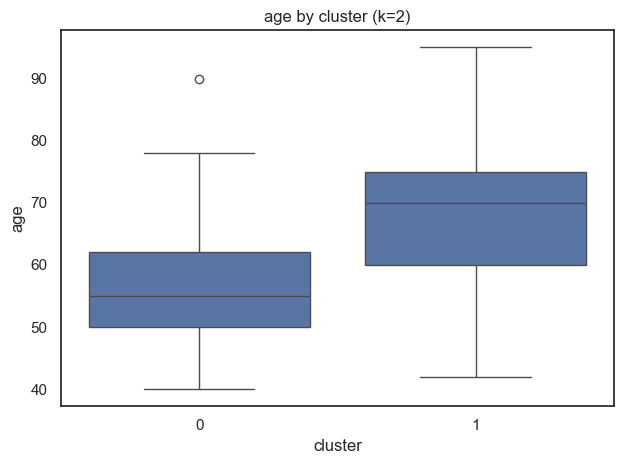

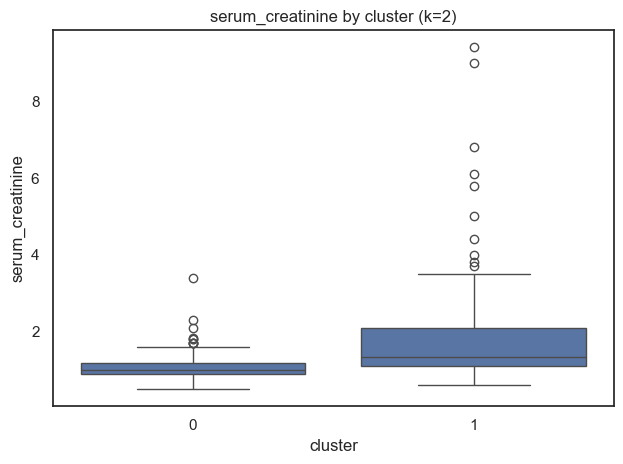

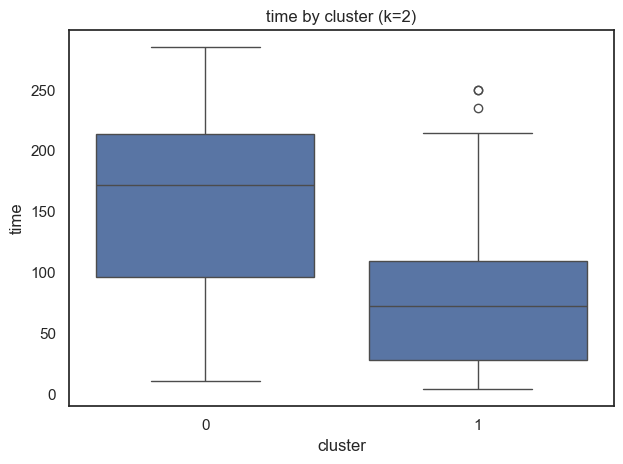

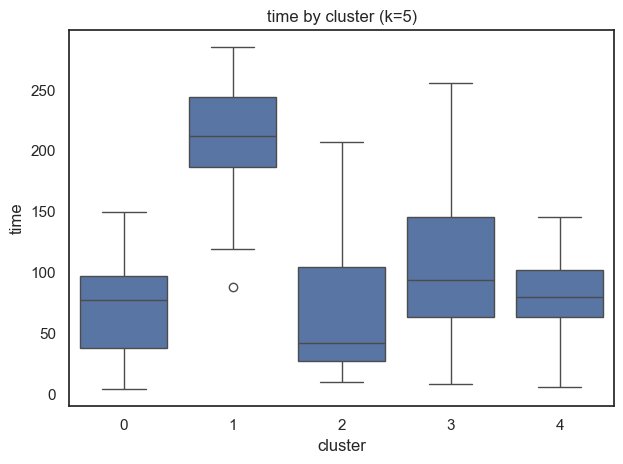

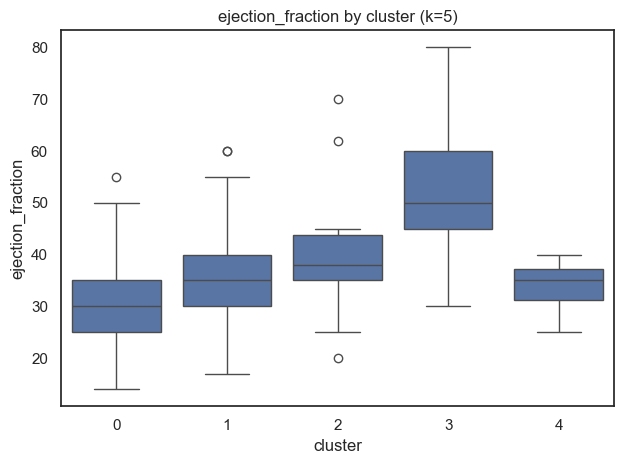

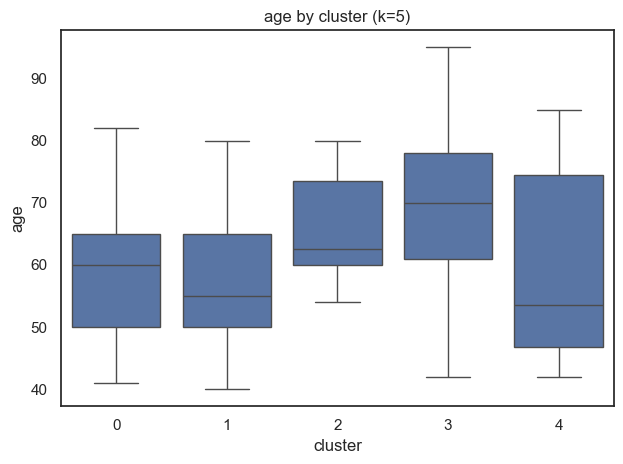

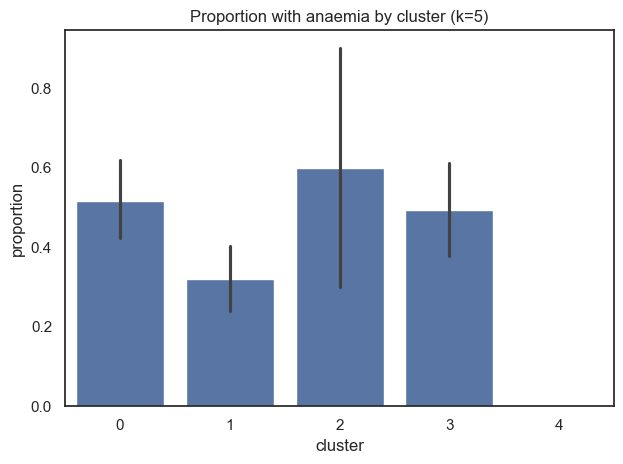

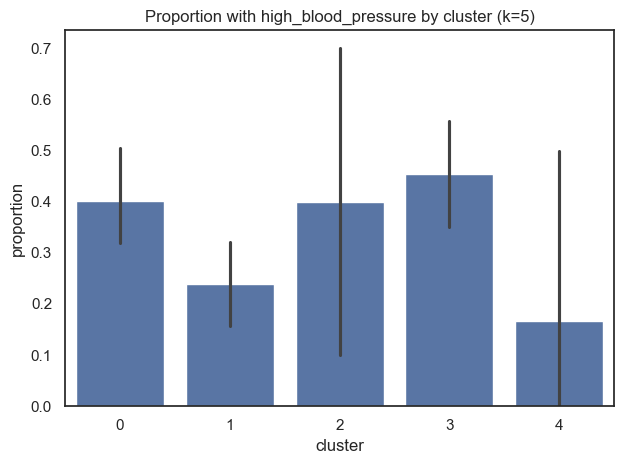

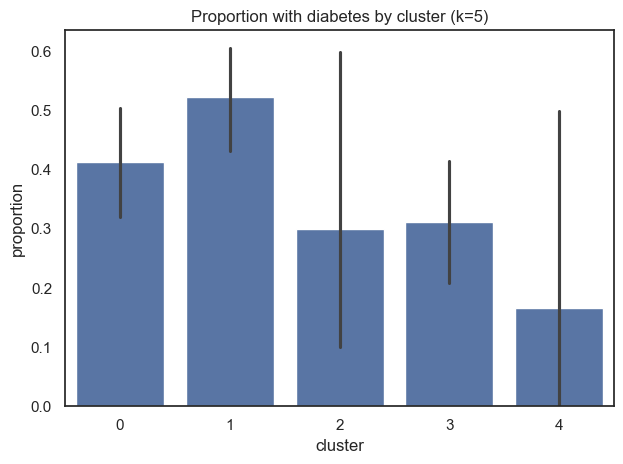

In [98]:
# choose key drivers automatically from previous tests
top_cont_k2 = cont_k2_tests.sort_values("p_fdr").index[:3].tolist()
top_cont_k5 = cont_k5_tests.sort_values("p_fdr").index[:3].tolist()
top_bin_k5  = bin_k5_tests.sort_values("p_fdr").index[:3].tolist()

# boxplots for key continuous variables (k=2)
for col in top_cont_k2:
    sns.boxplot(x="cluster_k2", y=col, data=df)
    plt.title(f"{col} by cluster (k=2)")
    plt.xlabel("cluster")
    plt.tight_layout()
    plt.show()

# boxplots for key continuous variables (k=5)
for col in top_cont_k5:
    sns.boxplot(x="cluster_k5", y=col, data=df)
    plt.title(f"{col} by cluster (k=5)")
    plt.xlabel("cluster")
    plt.tight_layout()
    plt.show()

# bar plots for key binary variables (k=5)
for col in top_bin_k5:
    sns.barplot(x="cluster_k5", y=col, data=df, estimator=np.mean)
    plt.title(f"Proportion with {col} by cluster (k=5)")
    plt.ylabel("proportion")
    plt.xlabel("cluster")
    plt.tight_layout()
    plt.show()


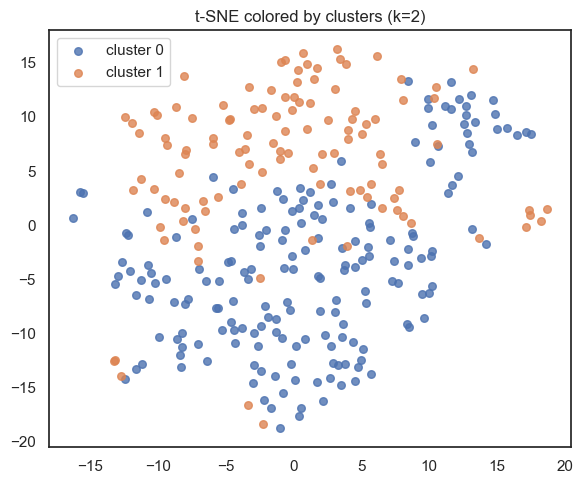

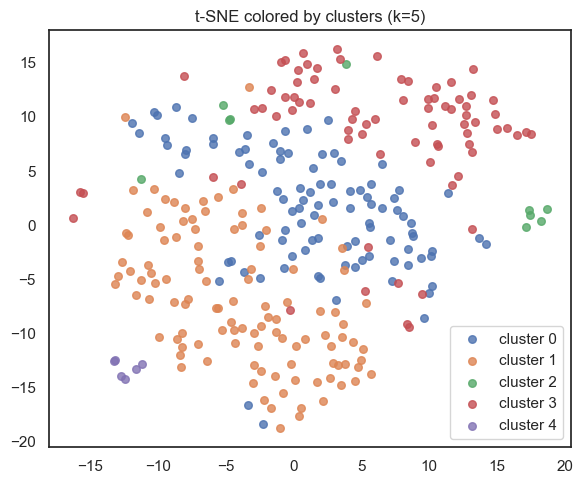

In [101]:
# t-SNE scatter to visualize separation in 2D
from sklearn.manifold import TSNE

# X is the design matrix you already built (scaled continuous + binaries)
tsne = TSNE(n_components=2, learning_rate="auto", init="random",
            random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# colored by cluster (k=2)
plt.figure(figsize=(6,5))
for c in sorted(df["cluster_k2"].unique()):
    m = df["cluster_k2"] == c
    plt.scatter(X_tsne[m,0], X_tsne[m,1], s=30, alpha=0.8, label=f"cluster {c}")
plt.title("t-SNE colored by clusters (k=2)")
plt.legend()
plt.tight_layout()
plt.show()

# colored by cluster (k=5)
plt.figure(figsize=(6,5))
for c in sorted(df["cluster_k5"].unique()):
    m = df["cluster_k5"] == c
    plt.scatter(X_tsne[m,0], X_tsne[m,1], s=30, alpha=0.8, label=f"cluster {c}")
plt.title("t-SNE colored by clusters (k=5)")
plt.legend()
plt.tight_layout()
plt.show()

